**Análisis Exploratorio de la Calidad del Aire: Dióxido de Azufre ($SO_2$) (2022 y 2023)**

1. Importamos paquetes

In [1]:
import numpy as np                  # Cálculos numéricos y manejo de arreglos/matrices
import pandas as pd                 # Organizar, limpiar y analizar datos en forma de tablas
import matplotlib.pyplot as plt     # Crear gráficos
import seaborn as sns               # Crear gráficos estadísticos más elaborados y visualmente agradables

%matplotlib inline

2. Importamos el conjunto de datos

In [3]:
# Carga del conjunto de datos descargado de la EPA para SO2 (2022 - 2023)
df = pd.read_csv("/content/SO2_daily_aqs_data_downloaded_2026-09-19 23_09_37.csv")

# Visualizamos las 5 primeras filas del DataFrame
df.head()

,Date,Site ID,POC,Daily Max SO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2022-01-01,10730023,2,-0.1,Parts per billion,0,North Birmingham,24,100,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
1,2022-01-02,10730023,2,-0.2,Parts per billion,0,North Birmingham,24,100,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
2,2022-01-03,10730023,2,-0.2,Parts per billion,0,North Birmingham,10,42,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
3,2022-01-04,10730023,2,1.9,Parts per billion,1,North Birmingham,9,38,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
4,2022-01-05,10730023,2,1.9,Parts per billion,1,North Birmingham,16,67,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN


3. Consultar información básica sobre el conjunto de datos

In [4]:
# Inspección de tipos de datos, cantidad de registros y columnas disponibles
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3581 entries, 0 to 3580
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          3581 non-null   object 
 1   Site ID                       3581 non-null   int64  
 2   POC                           3581 non-null   int64  
 3   Daily Max SO2 Concentration   3581 non-null   float64
 4   Units                         3581 non-null   object 
 5   Daily AQI Value               3581 non-null   int64  
 6   Local Site Name               3581 non-null   object 
 7   Daily Obs Count               3581 non-null   int64  
 8   Percent Complete              3581 non-null   int64  
 9   AQS Parameter Code            3581 non-null   int64  
 10  AQS Parameter Description     3581 non-null   object 
 11  Method Code                   3581 non-null   int64  
 12  Method Description            3581 non-null   object 
 13  CBS

4. Limpieza y preparación de los datos

In [5]:
# Convertimos la columna Date a formato de fecha (datetime)
df['Date'] = pd.to_datetime(df['Date'])

# Extraemos variables temporales que pueden influir en la concentración de SO2
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0 = Lunes ... 6 = Domingo

# Seleccionamos las columnas relevantes para el análisis predictivo
df = df[['Year', 'Month', 'Day', 'DayOfWeek', 'Daily Obs Count', 'Percent Complete',
         'Daily Max SO2 Concentration']]

# Renombramos columnas para facilitar su referencia en el código
df = df.rename(columns={
    'Daily Obs Count': 'Obs_Count',
    'Percent Complete': 'Percent_Complete',
    'Daily Max SO2 Concentration': 'SO2_Max'
})

# Visualizamos el DataFrame limpio y transformado
df.head()

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete,SO2_Max
0,2022,1,1,5,24,100,-0.1
1,2022,1,2,6,24,100,-0.2
2,2022,1,3,0,10,42,-0.2
3,2022,1,4,1,9,38,1.9
4,2022,1,5,2,16,67,1.9


5. describe () >> Resumen de estadísticas descriptivas

In [6]:
# Muestra un resumen estadístico (conteo, media, desviación estándar, min, max y percentiles)
df.describe().round(2)

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete,SO2_Max
count,3581.0,3581.00,3581.00,3581.0,3581.00,3581.00,3581.00
mean,2022.5,6.52,15.75,3.0,22.84,95.29,2.50
std,0.5,3.44,8.79,2.0,2.02,8.38,5.54
min,2022.0,1.00,1.00,0.0,2.00,8.00,-0.60
25%,2022.0,4.00,8.00,1.0,23.00,96.00,0.50
50%,2022.0,7.00,16.00,3.0,23.00,96.00,1.20
75%,2023.0,10.00,23.00,5.0,24.00,100.00,2.10
max,2023.0,12.00,31.00,6.0,24.00,100.00,72.70


6. columns >> obtiene los nombres de las características

In [7]:
# Consultamos el nombre exacto de las columnas procesadas
df.columns

Index(['Year', 'Month', 'Day', 'DayOfWeek', 'Obs_Count', 'Percent_Complete',
       'SO2_Max'],
      dtype='object')

7. Las relaciones entre todas las variables

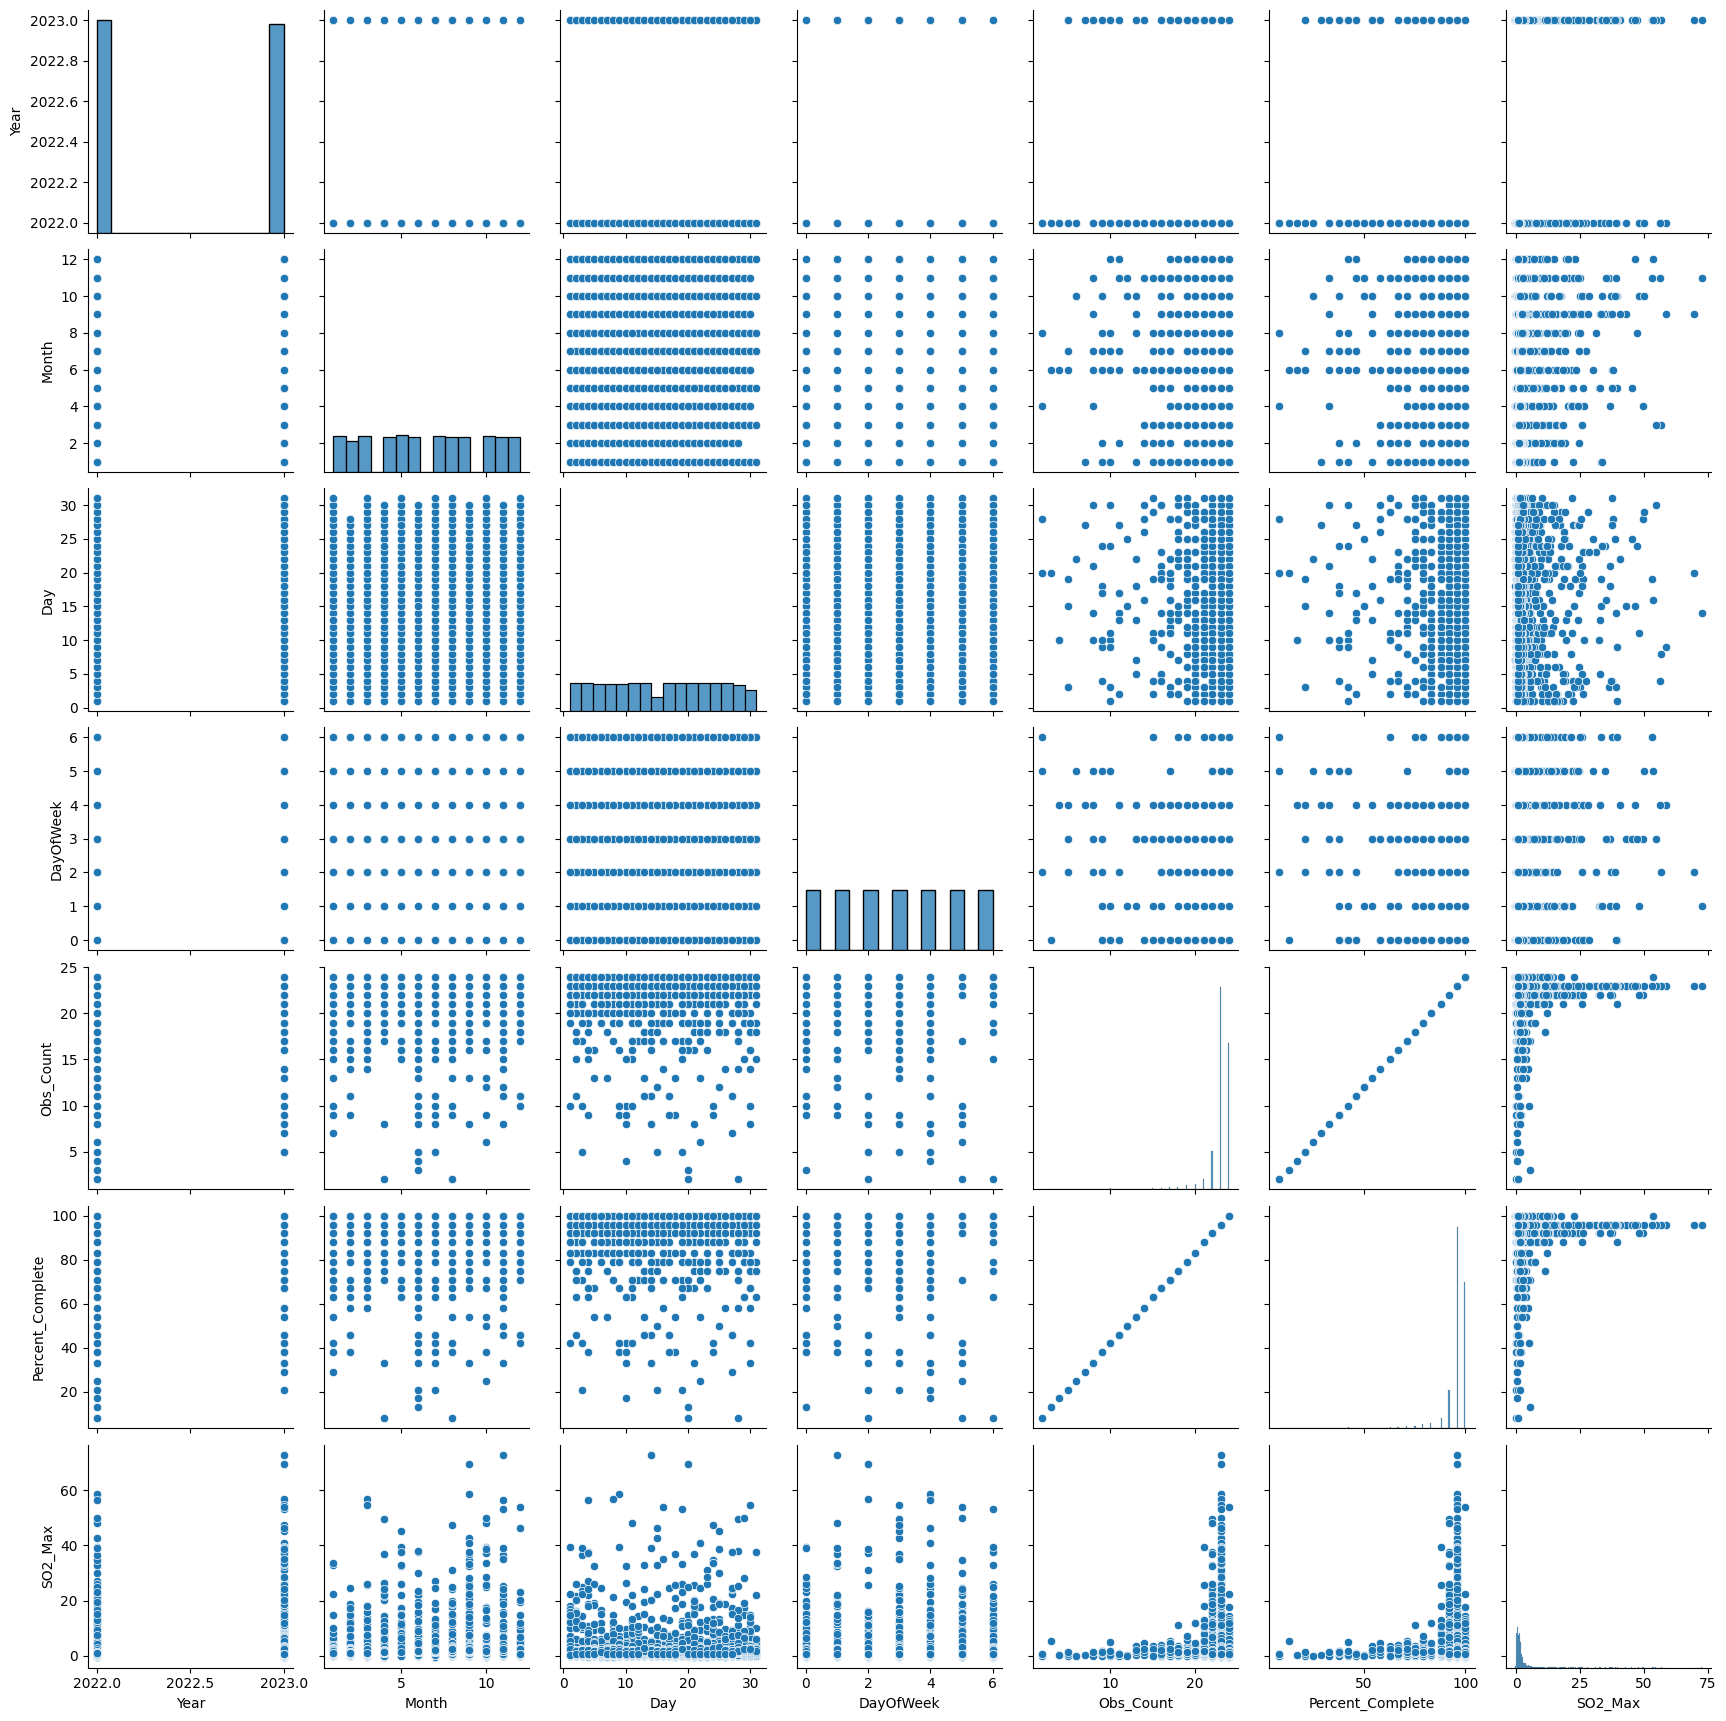

In [8]:
# Gráfico de dispersión cruzado entre todas las variables numéricas para identificar patrones
sns.pairplot(df)

8. Distribución de la concentración máxima diaria de $SO_2$

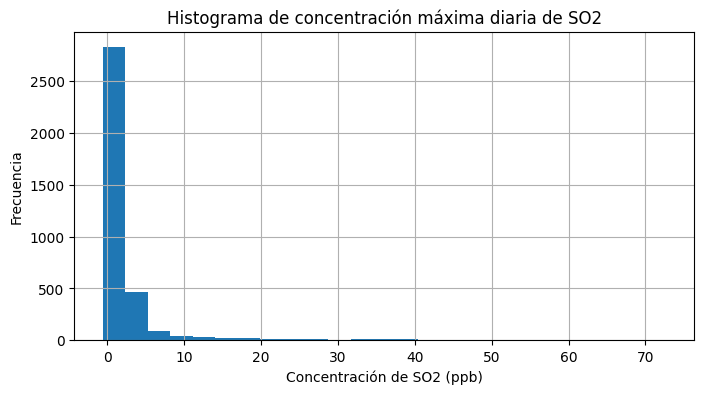

'Histograma: ¿Cómo se distribuyen los datos por intervalos?'

In [9]:
# Histograma en 25 intervalos
df['SO2_Max'].plot.hist(bins=25, figsize=(8, 4))
plt.title("Histograma de concentración máxima diaria de SO2")
plt.xlabel("Concentración de SO2 (ppb)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

'''Histograma: ¿Cómo se distribuyen los datos por intervalos?'''

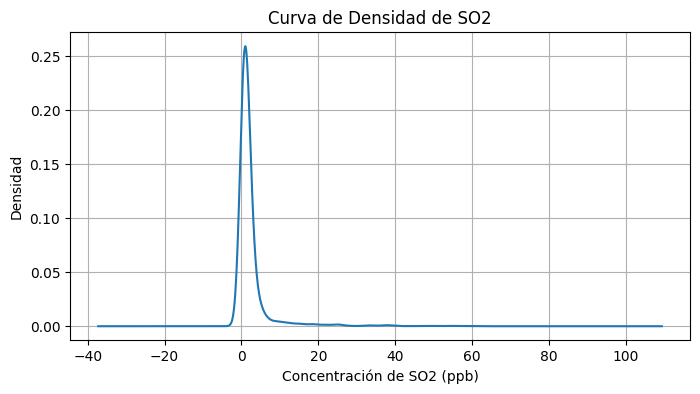

'Densidad: ¿Dónde están concentrados los datos?'

In [10]:
# Gráfico de estimación de densidad de probabilidad (KDE)
df['SO2_Max'].plot.density(figsize=(8, 4))
plt.title("Curva de Densidad de SO2")
plt.xlabel("Concentración de SO2 (ppb)")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

'''Densidad: ¿Dónde están concentrados los datos?'''

9. Matriz de correlación y heatmap

In [11]:
# Seleccionamos solo las columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Cálculo de la matriz de correlación de Pearson
numeric_df.corr().round(4)

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete,SO2_Max
Year,1.0000,0.0035,0.0031,0.0003,0.0756,0.0743,0.0699
Month,0.0035,1.0000,0.0107,0.0029,0.0329,0.0317,0.0602
Day,0.0031,0.0107,1.0000,-0.0111,-0.0060,-0.0061,-0.0015
DayOfWeek,0.0003,0.0029,-0.0111,1.0000,0.0886,0.0876,-0.0173
Obs_Count,0.0756,0.0329,-0.0060,0.0886,1.0000,0.9999,-0.0014
Percent_Complete,0.0743,0.0317,-0.0061,0.0876,0.9999,1.0000,0.0005
SO2_Max,0.0699,0.0602,-0.0015,-0.0173,-0.0014,0.0005,1.0000


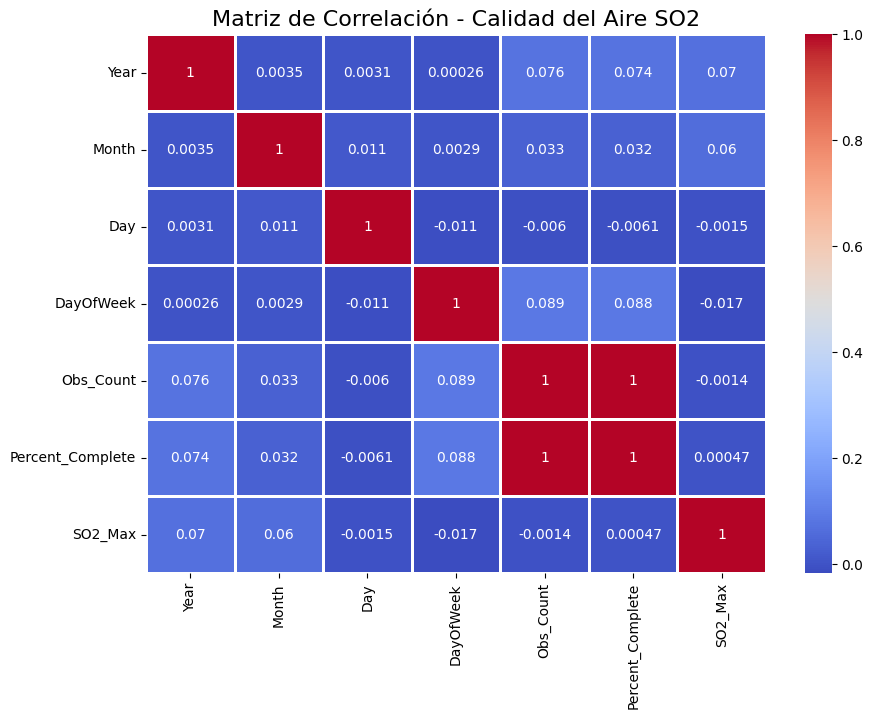

In [12]:
# Mapa de calor (Heatmap) de las correlaciones entre variables
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=2)
plt.title("Matriz de Correlación - Calidad del Aire SO2", fontsize=16)
plt.show()

10. Conjunto de características y variables

In [13]:
# Lista de nombres de columnas
l_column = list(df.columns)
len_feature = len(l_column)

# Definimos las variables predictoras (X) y la variable objetivo (Y)
X = df[l_column[0:len_feature-1]]   # Variables predictoras (Year, Month, Day, DayOfWeek, Obs_Count, Percent_Complete)
Y = df[l_column[len_feature-1]]     # Variable objetivo: SO2_Max

# Muestreo inicial de X y Y
X.head()

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete
0,2022,1,1,5,24,100
1,2022,1,2,6,24,100
2,2022,1,3,0,10,42
3,2022,1,4,1,9,38
4,2022,1,5,2,16,67


In [14]:
Y.head()

,SO2_Max
0,-0.1
1,-0.2
2,-0.2
3,1.9
4,1.9


11. Definimos entrenamiento - prueba

In [15]:
from sklearn.model_selection import train_test_split

# Dividimos los datos en 70% entrenamiento y 30% prueba con semilla fijada para reproducibilidad
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=123
)

12. Ajuste y entrenamiento del modelo de Regresión Lineal

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Creación del objeto de Regresión Lineal
lm = LinearRegression()

# Entrenamiento del modelo con los datos de entrenamiento
lm.fit(X_train, Y_train)

# Verificamos la intersección y los coeficientes obtenidos
print("El término de intersección del modelo lineal:", lm.intercept_)
print("Los coeficientes del modelo lineal:", lm.coef_)

# Construimos el DataFrame de coeficientes
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
cdf

El término de intersección del modelo lineal: -1991.7930032263212
Los coeficientes del modelo lineal: [ 9.85024881e-01  1.03835849e-01 -4.77623053e-03 -1.35128131e-02
 -2.29800872e+01  5.52468172e+00]


,Coefficients
Year,0.985025
Month,0.103836
Day,-0.004776
DayOfWeek,-0.013513
Obs_Count,-22.980087
Percent_Complete,5.524682


13. Cálculo de errores estándar y estadística $t$ para los coeficientes

In [17]:
# Cálculo formal del error estándar y la estadística t para evaluar significancia
n = X_train.shape[0]   # Cantidad de datos de entrenamiento
k = X_train.shape[1]   # Cantidad de variables predictoras
dfN = n - k             # Grados de libertad

train_pred = lm.predict(X_train)
train_error = np.square(train_pred - Y_train)
sum_error = np.sum(train_error)

se = [0] * k
for i in range(k):
    r = (sum_error / dfN)
    r = r / np.sum(np.square(X_train[list(X_train.columns)[i]] - X_train[list(X_train.columns)[i]].mean()))
    se[i] = np.sqrt(r)  # Cálculo del error estándar

cdf['Standard Error'] = se
cdf['t_statistic'] = cdf['Coefficients'] / cdf['Standard Error']
cdf

,Coefficients,Standard Error,t_statistic
Year,0.985025,0.225895,4.360535
Month,0.103836,0.033058,3.140980
Day,-0.004776,0.012774,-0.373915
DayOfWeek,-0.013513,0.056665,-0.238470
Obs_Count,-22.980087,0.058794,-390.859097
Percent_Complete,5.524682,0.014160,390.163871


14. Gráficos de dispersión individuales de variables vs. $SO_2$

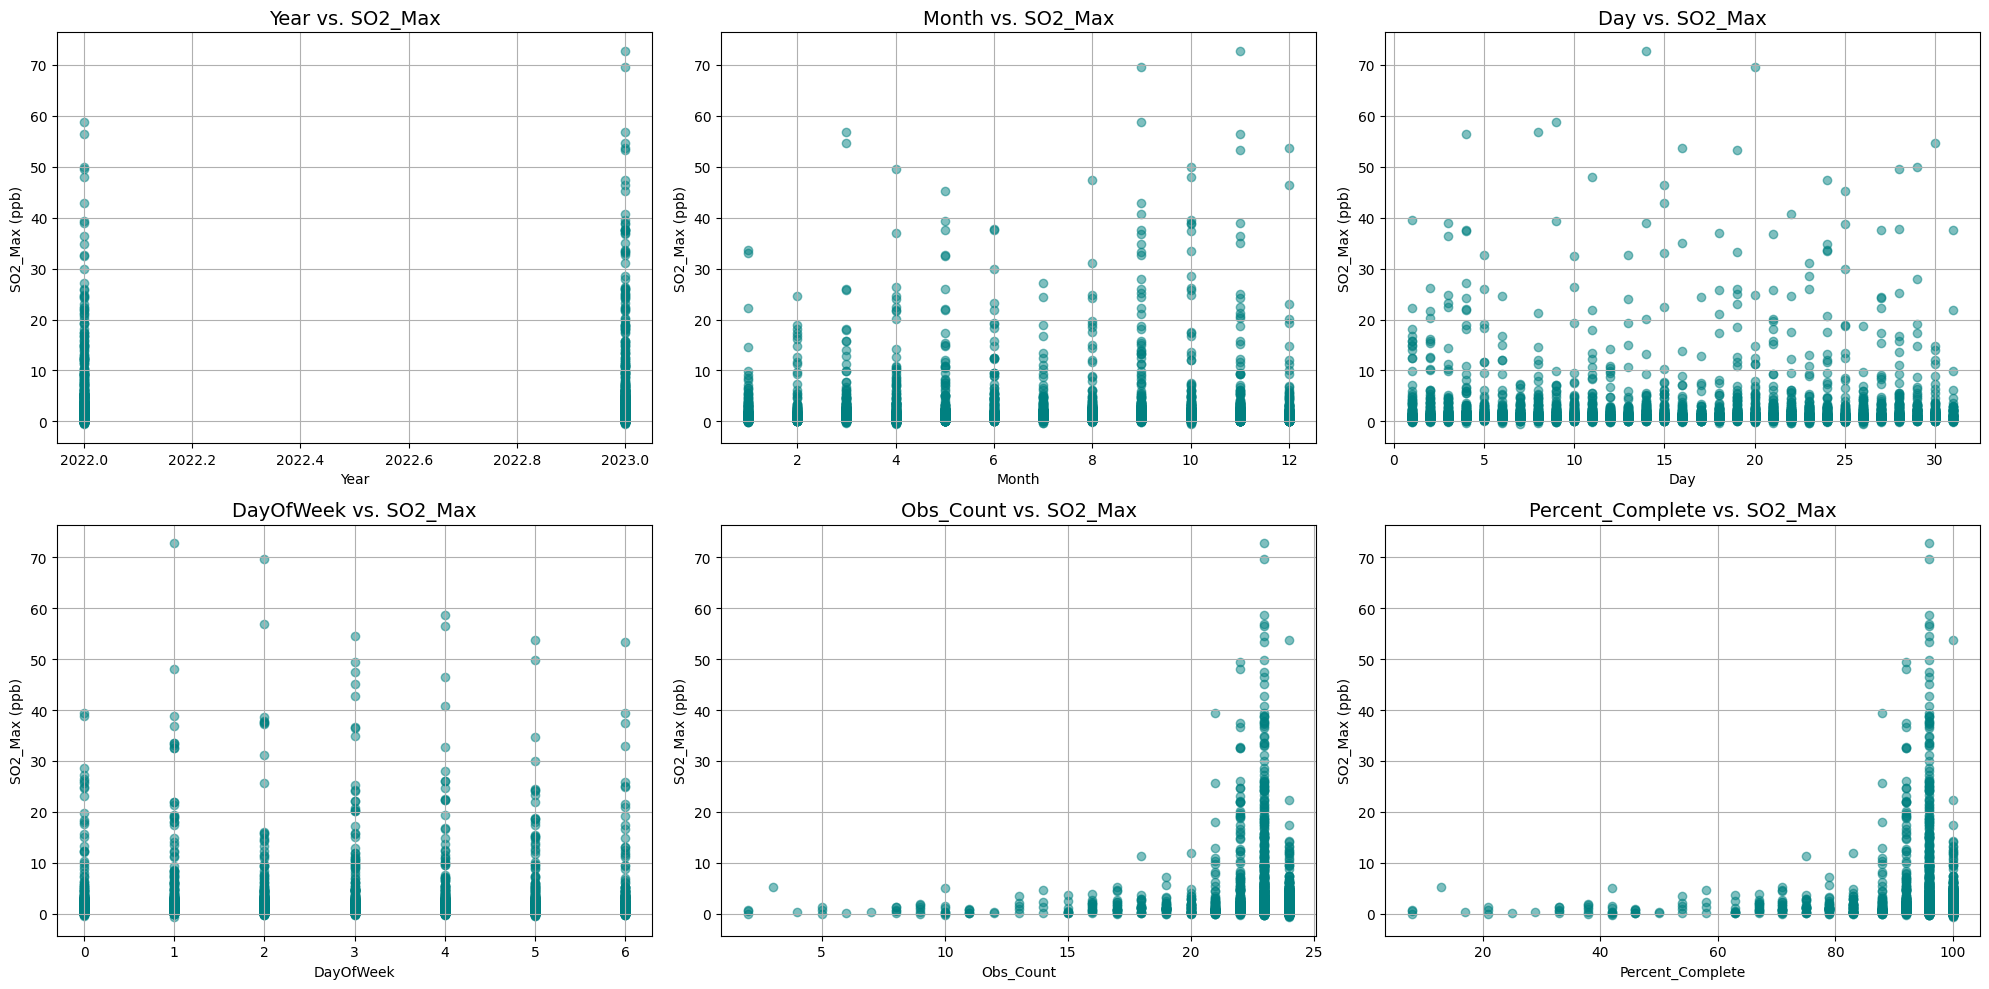

In [18]:
from matplotlib import gridspec

l = list(cdf.index)
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 3)

for i, col in enumerate(l):
    ax = plt.subplot(gs[i])
    ax.scatter(df[col], df['SO2_Max'], alpha=0.5, color='teal')
    ax.set_title(col + " vs. SO2_Max", fontdict={'fontsize': 14})
    ax.set_xlabel(col)
    ax.set_ylabel("SO2_Max (ppb)")
    ax.grid(True)

plt.tight_layout()
plt.show()

15. Evaluación de predicciones y diagnóstico de residuos

In [19]:
# Obtenemos las predicciones para el conjunto de prueba (X_test)
predictions = lm.predict(X_test)

print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (1075,)


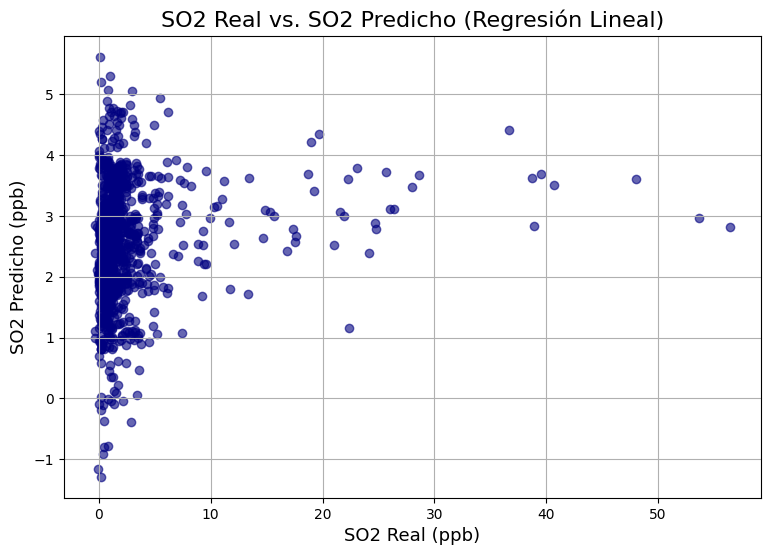

In [20]:
# Diagrama de dispersión: Valores Reales vs. Predichos
plt.figure(figsize=(9, 6))
plt.title("SO2 Real vs. SO2 Predicho (Regresión Lineal)", fontsize=16)
plt.xlabel("SO2 Real (ppb)", fontsize=13)
plt.ylabel("SO2 Predicho (ppb)", fontsize=13)
plt.scatter(x=Y_test, y=predictions, alpha=0.6, color='navy')
plt.grid(True)
plt.show()

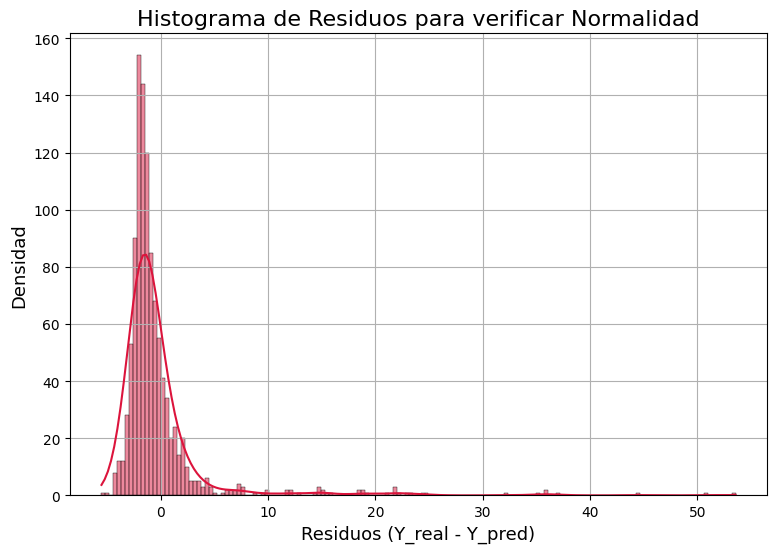

In [21]:
# Histograma e inspección de Normalidad de Residuos
plt.figure(figsize=(9, 6))
plt.title("Histograma de Residuos para verificar Normalidad", fontsize=16)
plt.xlabel("Residuos (Y_real - Y_pred)", fontsize=13)
plt.ylabel("Densidad", fontsize=13)
sns.histplot((Y_test - predictions), kde=True, color='crimson')
plt.grid(True)
plt.show()

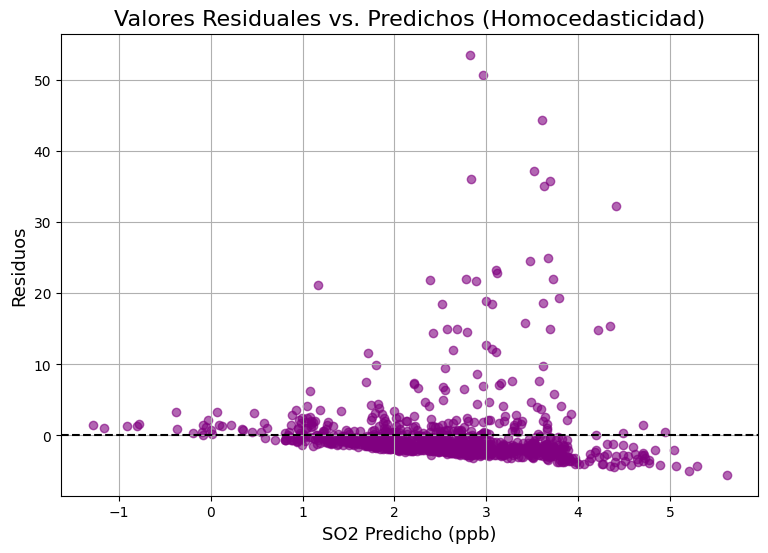

In [22]:
# Evaluación de Homocedasticidad: Residuos vs. Predichos
plt.figure(figsize=(9, 6))
plt.title("Valores Residuales vs. Predichos (Homocedasticidad)", fontsize=16)
plt.xlabel("SO2 Predicho (ppb)", fontsize=13)
plt.ylabel("Residuos", fontsize=13)
plt.scatter(x=predictions, y=Y_test - predictions, alpha=0.6, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.grid(True)
plt.show()

16. Modelo de Árbol de Decisión para Regresión

In [23]:
from sklearn import tree
from sklearn import metrics

# Creación del modelo de Árbol de Decisión limitando la profundidad a 5 niveles para evitar overfitting
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)

# Ajuste del modelo con los mismos datos de entrenamiento usados en la regresión lineal
tree_model.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

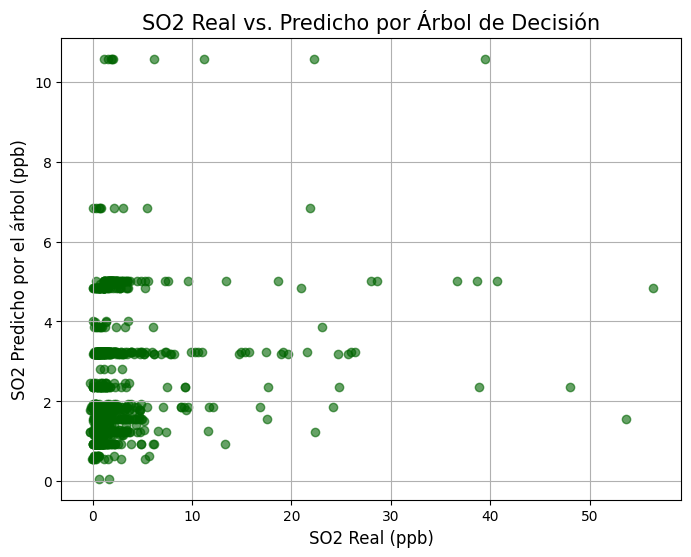

Error cuadrático medio (MSE): 25.10454662787893


In [24]:
# Evaluamos las predicciones del árbol sobre el conjunto de prueba
tree_pred = tree_model.predict(X_test)

# Gráfico de dispersión: Valores Reales vs. Predichos por el Árbol
plt.figure(figsize=(8, 6))
plt.scatter(x=Y_test, y=tree_pred, alpha=0.6, color='darkgreen')
plt.title("SO2 Real vs. Predicho por Árbol de Decisión", fontsize=15)
plt.xlabel("SO2 Real (ppb)", fontsize=12)
plt.ylabel("SO2 Predicho por el árbol (ppb)", fontsize=12)
plt.grid(True)
plt.show()

# Cálculo del Error Cuadrático Medio (MSE)
print("Error cuadrático medio (MSE):", metrics.mean_squared_error(Y_test, tree_pred))

17. Importancia relativa de las características en el Árbol de Decisión

Importancia relativa de las características: [0.14665395 0.23814819 0.2207207  0.05885128 0.06384447 0.27178142]


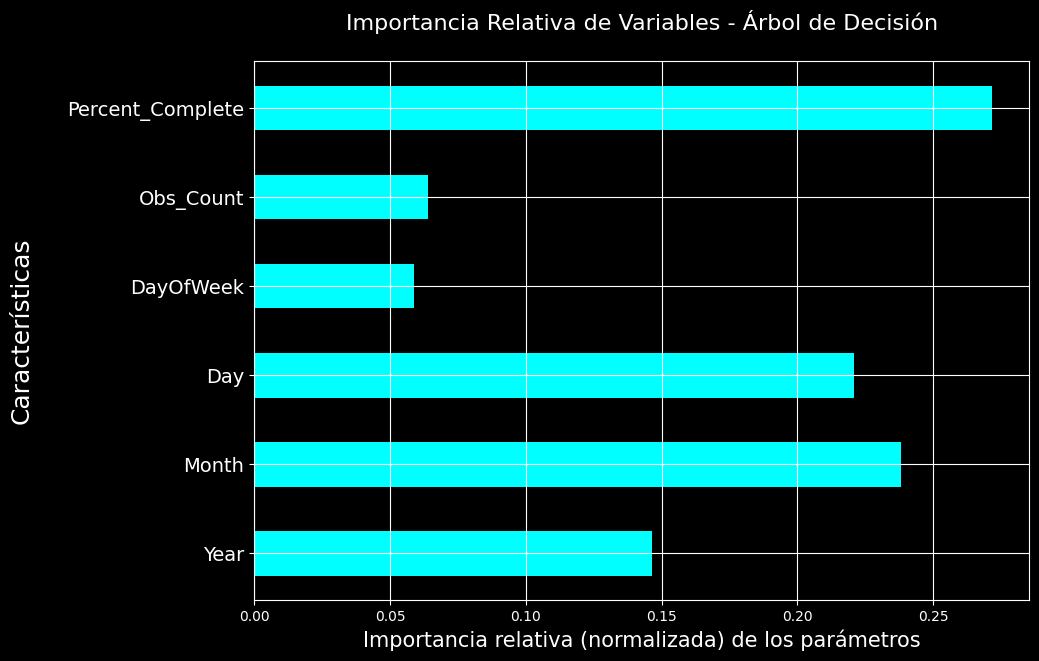

In [25]:
# Imprimimos los valores numéricos de la importancia de cada variable
print("Importancia relativa de las características:", tree_model.feature_importances_)

# Visualización mediante gráfico de barras horizontales
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(len(X.columns)), X.columns, fontsize=14)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=18)
    plt.barh(range(len(X.columns)), width=tree_model.feature_importances_, height=0.5, color='cyan')
    plt.title("Importancia Relativa de Variables - Árbol de Decisión\n", fontsize=16)
    plt.show()

18. Mínimos Cuadrados Ordinarios (OLS) sobre el conjunto de datos de $SO_2$ (2022-2023)

In [26]:
import statsmodels.api as sm

# Añadimos la constante al conjunto de variables predictoras
Xs = sm.add_constant(X)

# Definimos y ajustamos el modelo OLS
stat_model = sm.OLS(Y, Xs)
stat_result = stat_model.fit()

# Imprimimos el resumen estadístico completo
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                SO2_Max   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     14.78
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           9.31e-17
Time:                        03:36:32   Log-Likelihood:                -11166.
No. Observations:                3581   AIC:                         2.235e+04
Df Residuals:                    3574   BIC:                         2.239e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1788.3957    372.204  